# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**

**1.** $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$ — **выпукло**. Это надграфик функции $\varphi(x_1) = x_1^2$: $\varphi''(x_1) = 2 > 0$, значит $\varphi$ выпукла, а надграфик выпуклой функции всегда выпуклое множество.

**2.** $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ — **выпукло** при любых $A, b$. Функция $f(x) = \Vert Ax - b\Vert_2$ — композиция нормы (выпуклой) с аффинным отображением $x \mapsto Ax - b$, значит $f$ выпукла; множество $\{f \le 1\}$ — подуровневое множество выпуклой функции, а такие множества всегда выпуклы.

**3.** $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$ — **не выпукло**. Контрпример: точки $(1, 0)$ и $(-1, 0)$ лежат в множестве ($\Vert x\Vert_2 = 1$), но их середина $(0, 0)$ имеет норму $0 < 1$ и множеству не принадлежит.


**(б)**

**Ответ:**

**1.** $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$, гессиан постоянный:
$$\nabla^2 f = \begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix}.$$
Собственные значения симметричной $2\times2$ матрицы $\begin{pmatrix}p&a\\a&p\end{pmatrix}$ равны $p \pm a$, здесь $p=2$, то есть $\lambda_{1,2} = 2 \mp a$. По критерию второго порядка $f$ выпукла на $\mathbb{R}^2$ (гессиан всюду один и тот же, поэтому "выпукла на $\mathbb{R}^2$" $\iff$ "гессиан $\succeq 0$") тогда и только тогда, когда $2-a\ge0$ и $2+a\ge0$, то есть
$$-2 \le a \le 2.$$
Строго выпукла (гессиан $\succ 0$, обе собственные строго положительны) при
$$-2 < a < 2.$$
На границе $a=\pm2$ гессиан вырожден ($\det = 4-a^2=0$) — выпукла, но не строго.

**2.** $g(x) = x_1^2 x_2^2$ **не выпукла** на $\mathbb{R}^2$. Гессиан:
$$\nabla^2 g(x) = \begin{pmatrix} 2x_2^2 & 4x_1x_2 \\ 4x_1x_2 & 2x_1^2 \end{pmatrix}, \qquad \det \nabla^2 g(x) = 4x_1^2x_2^2 - 16x_1^2x_2^2 = -12\,x_1^2x_2^2.$$
При любых $x_1\ne0,\ x_2\ne0$ определитель отрицателен, значит гессиан имеет одно положительное и одно отрицательное собственное значение — не является положительно полуопределённым. Например, в точке $x=(1,1)$: $\nabla^2 g = \begin{pmatrix}2&4\\4&2\end{pmatrix}$, собственные значения $6$ и $-2$ — критерий второго порядка нарушен, $g$ не выпукла


In [2]:
# проверка (б).1: гессиан f(x) = x1^2 + a x1 x2 + x2^2 при разных a
for a in [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    H = np.array([[2.0, a], [a, 2.0]])
    eigs = np.linalg.eigvalsh(H)
    print(f"a = {a:5.1f}:  eigvals = {eigs},  convex = {bool(np.all(eigs >= -1e-12))}")

print()

# проверка (б).2: гессиан g(x) = x1^2 x2^2 в нескольких точках
def hess_g(x1, x2):
    return np.array([[2 * x2**2, 4 * x1 * x2],
                      [4 * x1 * x2, 2 * x1**2]])

for x1, x2 in [(1.0, 1.0), (2.0, -1.0), (0.5, 3.0)]:
    eigs = np.linalg.eigvalsh(hess_g(x1, x2))
    print(f"x = ({x1}, {x2}):  eigvals = {eigs},  convex here = {bool(np.all(eigs >= -1e-12))}")


a =  -3.0:  eigvals = [-1.  5.],  convex = False
a =  -2.0:  eigvals = [0. 4.],  convex = True
a =  -1.0:  eigvals = [1. 3.],  convex = True
a =   0.0:  eigvals = [2. 2.],  convex = True
a =   1.0:  eigvals = [1. 3.],  convex = True
a =   2.0:  eigvals = [0. 4.],  convex = True
a =   3.0:  eigvals = [-1.  5.],  convex = False

x = (1.0, 1.0):  eigvals = [-2.  6.],  convex here = False
x = (2.0, -1.0):  eigvals = [-3.54400375 13.54400375],  convex here = False
x = (0.5, 3.0):  eigvals = [-1.35954759 19.85954759],  convex here = False


**(в)**

**Ответ:**

**1.** $f(x) = \Vert Ax-b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$ — **выпукла**. Оба слагаемых выпуклы: $\Vert Ax-b\Vert_2$ — норма от аффинного выражения (композиция выпуклой $\Vert\cdot\Vert_2$ с аффинным $x\mapsto Ax-b$); $\Vert x\Vert_\infty$ — норма, выпукла сама по себе, а умножение на константу $\lambda\ge0$ сохраняет выпуклость. Сумма выпуклых функций выпукла

**2.** $f(x) = \max_i \big(a_i^\top x - b_i\big)^2$ — **выпукла**. Каждая функция $h_i(x) = a_i^\top x - b_i$ аффинна, а $g(z) = z^2$ выпукла на $\mathbb{R}$; для аффинного $h_i$ композиция $g(h_i(x)) = (a_i^\top x-b_i)^2$ выпукла независимо от монотонности $g$ (правило "выпуклая от аффинной"). Поточечный максимум выпуклых функций выпукл, значит и $f$ выпукла.

**3.** $f(x) = e^{-\Vert x\Vert_2^2}$ — **не выпукла**. Правила раздела 5 не применимы: это композиция $g(z)=e^{-z}$ (убывающая) с $h(x)=\Vert x\Vert_2^2$ (выпуклой) — а правило "выпуклая от выпуклой" требует, чтобы внешняя функция была *не убывающей*, здесь же $g$ убывает, поэтому композиция может оказаться невыпуклой.

Контрпример: возьмём точки $x_1=-M$, $x_2=M$ при большом $M$. Тогда
$$f(x_1)=f(x_2)=e^{-M^2}\approx 0, \qquad f\!\left(\tfrac{x_1+x_2}{2}\right)=f(0)=1.$$
Выпуклость требует $f(0) \le \tfrac12 f(x_1)+\tfrac12 f(x_2) \approx 0$, но $f(0)=1$ — неравенство нарушено

**Гладкость**

**1.** $f(x) = \Vert Ax-b\Vert_2 + \lambda\,\Vert x\Vert_\infty$ — **не гладкая**. Норма $\Vert z\Vert_2$ не дифференцируема в нуле, поэтому $\Vert Ax-b\Vert_2$ не дифференцируема в точках, где $Ax=b$; аналогично $\Vert x\Vert_\infty$ не дифференцируема там, где максимум $|x_i|$ достигается сразу на нескольких координатах (например, в $x=0$). В этих точках нарушается гладкость всей суммы.

**2.** $f(x) = \max_i \big(a_i^\top x - b_i\big)^2$ — **не гладкая**. Каждое слагаемое гладкое, но поточечный максимум нескольких гладких функций гладким не является: в точках, где максимум одновременно достигается на двух и более индексах $i$, производная терпит разрыв

**3.** $f(x) = e^{-\Vert x\Vert_2^2}$ — **гладкая** (бесконечно дифференцируема всюду). $\Vert x\Vert_2^2$ — многочлен от координат $x$, $e^{-z}$ — гладкая функция на $\mathbb{R}$, их композиция гладкая на всём $\mathbb{R}^n$.


**(г)**

**Ответ:**

цель → равенства → неравенства.

**(а) Ближайшая точка прямой.** Цель $f(x) = (x_1-1)^2+(x_2-2)^2+(x_3-3)^2$ — сумма квадратов, гессиан $2I \succ 0$ — строго выпукла. Равенства $g(x) = \big(x_1+x_2+x_3-1,\; x_1-x_3\big) = 0$ — аффинные, их множество решений (прямая) — аффинное подпространство, всегда выпуклое. Неравенств нет. Все три пункта чек-листа выполнены — задача **выпукла** (QP).

**(б) Диета.** Цель $f(x)=c^\top x$ — линейная, выпукла (и вогнута) при любом $c$. Равенств нет. Неравенства $h(x) = (Ax-b,\ x) \ge 0$ — аффинные функции координат $x$, их допустимое множество — пересечение полупространств (многогранник), выпуклое. Задача **выпукла** (LP).

**(в) Вписанный прямоугольник.** Цель $f(x)=-4ab$ — гессиан $\begin{pmatrix}0&-4\\-4&0\end{pmatrix}$ знаконеопределён (собственные значения $\pm4$), значит $f$ **не выпукла**

**(г) Подгонка $\varphi(t;x)=x_1\sin(x_2 t+x_3)$.** Цель $f(x)=\sum_i(\varphi(t_i;x)-y_i)^2$ — сумма квадратов, но $\varphi(t_i;\cdot)$ нелинейна и не аффинна по $x$ (параметры $x_2,x_3$ стоят внутри $\sin$), а функция $\varphi\mapsto(\varphi-y_i)^2$ выпукла лишь как композиция с *аффинной* функцией внутри; здесь же внутренняя функция $x\mapsto x_1\sin(x_2t+x_3)$ не аффинна и не выпукла/вогнута сама по себе (синус меняет знак кривизны), поэтому правило "выпуклая от аффинной" не работает, и композиция $f$ **не выпукла**

**(д) Чебышёвская подгонка.** После переформулировки: цель $f(x,s)=s$ — линейная, выпукла. Равенств нет. Неравенства $h(x,s) = \big(s-(a_i^\top x-b_i),\ s+(a_i^\top x-b_i)\big) \ge 0$ — аффинные по $(x,s)$, допустимое множество — пересечение полупространств, выпуклое. Задача **выпукла** (LP).


## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:**

Задача выпукла ($f$ строго выпукла, $\Omega$ — полупространство), поэтому условие $\nabla f(x^\ast)^\top(y-x^\ast)\ge0\ \forall y\in\Omega$, $\nabla f(x)=x-p$, необходимо и достаточно.

**(i)** Если $a^\top x^\ast < b$ (строго внутри), возьмём $y=x^\ast-\varepsilon(x^\ast-p)$ — при малом $\varepsilon$ допустима, и $\nabla f(x^\ast)^\top(y-x^\ast)=-\varepsilon\Vert x^\ast-p\Vert^2<0$ — противоречие. Значит $a^\top x^\ast=b$.

**(ii)** Для $v\perp a$ точки $y_\pm=x^\ast\pm v$ допустимы ($a^\top y_\pm=b$). Условие для обоих знаков даёт $(x^\ast-p)^\top v=0\ \forall v\perp a$, значит $x^\ast-p \parallel a$: $x^\ast=p-\lambda a$.

**(iii)** Из $a^\top x^\ast=b$: $a^\top p-\lambda\Vert a\Vert^2=b \Rightarrow \lambda=\dfrac{a^\top p-b}{\Vert a\Vert^2}>0$ (так как $a^\top p>b$). Итого
$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\,a.$$

**(iv)** Для любого $y\in\Omega$: $(x^\ast-p)^\top(y-x^\ast)=-\lambda(a^\top y-b)\ge0$, так как $a^\top y\le b$ и $\lambda>0$. Условие выполнено для всех $y$, значит $x^\ast$ — решение.


**Численная проверка (пункты 2 и 3)**

In [4]:
# --- пункт 1: формула ---
lam = (a @ p - b) / (a @ a)
x_formula = p - lam * a
print("x* по формуле =", x_formula)

# --- пункт 2: численно через SLSQP ---
def f(x):
    return 0.5 * np.sum((x - p) ** 2)

def grad_f(x):
    return x - p

constraints = [{"type": "ineq", "fun": lambda x: b - a @ x}]   # a@x <= b  <=>  b - a@x >= 0
res = minimize(f, x0=p, jac=grad_f, method="SLSQP", constraints=constraints)
x_num = res.x
print("x* численно (SLSQP) =", x_num)
print("невязка с формулой =", np.linalg.norm(x_num - x_formula))

# --- пункт 3: проверка условия оптимальности ---
def sample_feasible(n_points, box=5.0, rng_=None):
    rng_ = rng_ or rng
    pts = []
    while len(pts) < n_points:
        cand = rng_.uniform(-box, box, (n_points, 3))
        mask = cand @ a <= b
        pts.extend(cand[mask])
    return np.array(pts[:n_points])

Y = sample_feasible(2000)

# в оптимальной точке x*
vals_opt = (grad_f(x_formula) @ (Y - x_formula).T)
print("\nв x* (оптимум):     min grad^T(y-x*) =", vals_opt.min())

# в заведомо неоптимальной допустимой точке x=0
x0 = np.zeros(3)
assert a @ x0 <= b   # x=0 допустима
vals_zero = (grad_f(x0) @ (Y - x0).T)
print("в x=0 (не оптимум): min grad^T(y-x)  =", vals_zero.min())


x* по формуле = [ 2.41666667 -0.16666667  1.08333333]
x* численно (SLSQP) = [ 2.41666667 -0.16666667  1.08333333]
невязка с формулой = 8.308148362110449e-16

в x* (оптимум):     min grad^T(y-x*) = 6.749882062785036e-05
в x=0 (не оптимум): min grad^T(y-x)  = -16.471891311309996


**Ответ:**

Численная проекция (SLSQP) совпала с формулой с точностью $\sim10^{-16}$.

Проверка условия оптимальности: в $x^\ast$ минимум $\nabla f(x)^\top(y-x)$ по 2000 случайным допустимым $y$ практически ноль ($\ge0$, как и требуется). В $x=0$ (допустима, но не оптимальна) минимум сильно отрицателен ($\approx-16.5$) — значит, есть допустимое направление, уменьшающее $f$, то есть $x=0$ не минимум.


**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

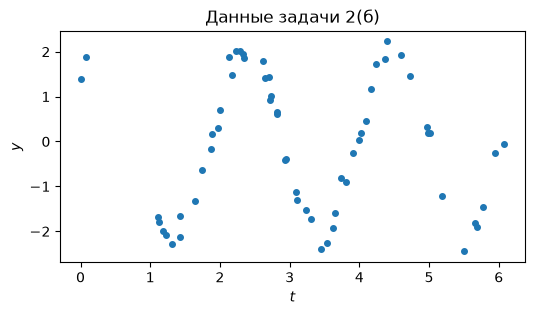

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:**

**Модель B** линейна по $x$ ($\varphi_B=\phi(t)^\top x$, $\phi(t)=(\sin\omega t,\cos\omega t)$), поэтому $f_B(x)=\tfrac12\Vert Ax-y\Vert^2$ — сумма квадратов аффинной функции, гессиан $A^\top A\succeq0$ постоянен. Задача **выпуклая** (QP).

**Модель A** нелинейна по $x_2,x_3$ (внутри $\sin$), $f_A$ **не выпукла**. Две симметрии: при $x_3\to x_3+2\pi$ значение $f_A$ не меняется ($\sin$ $2\pi$-периодичен) — периодичность несовместима с выпуклостью невырожденной функции; при $(x_1,x_3)\to(-x_1,x_3+\pi)$ значение тоже не меняется ($\sin(\cdot+\pi)=-\sin(\cdot)$). Это даёт разные минимумы $x^{(1)},x^{(2)}$, чья середина не является минимумом — противоречит тому, что у выпуклой функции множество минимумов выпукло.


**Мультистарт (пункт 2)**

f_A по стартам:
[ 1.1393 63.8249  1.1393  1.1393  1.1393 61.4973 61.4973 64.2518  1.1393
 63.8249  1.1393  1.1393 61.4973  1.1393 64.2518  1.1393 61.6882  1.1393
 61.4973  1.1393]
f_B по стартам:
[1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408
 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408 1.1408]

наименьшее f_A = 1.139273, доля стартов, дошедших до него: 0.55
наименьшее f_B = 1.140764, доля стартов, дошедших до него: 1.00


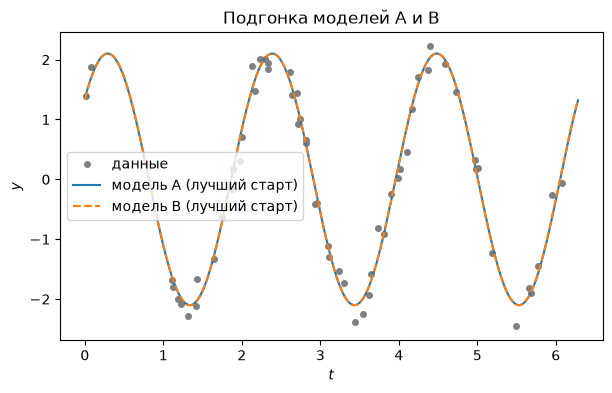

In [6]:
def f_A(x, t=t, y=y):
    return 0.5 * np.sum((x[0] * np.sin(x[1] * t + x[2]) - y) ** 2)

def f_B(x, t=t, y=y, omega=omega):
    return 0.5 * np.sum((x[0] * np.sin(omega * t) + x[1] * np.cos(omega * t) - y) ** 2)

fA_vals = np.zeros(len(starts))
fB_vals = np.zeros(len(starts))
xA_sols = []
xB_sols = []

for k, x0 in enumerate(starts):
    resA = minimize(f_A, x0, method="BFGS")
    resB = minimize(f_B, x0[:2], method="BFGS")
    fA_vals[k] = resA.fun
    fB_vals[k] = resB.fun
    xA_sols.append(resA.x)
    xB_sols.append(resB.x)

print("f_A по стартам:")
print(np.round(fA_vals, 4))
print("f_B по стартам:")
print(np.round(fB_vals, 4))

tol = 1e-4
best_A, best_B = fA_vals.min(), fB_vals.min()
frac_A = np.mean(fA_vals < best_A + tol)
frac_B = np.mean(fB_vals < best_B + tol)
print(f"\nнаименьшее f_A = {best_A:.6f}, доля стартов, дошедших до него: {frac_A:.2f}")
print(f"наименьшее f_B = {best_B:.6f}, доля стартов, дошедших до него: {frac_B:.2f}")

x_best_A = xA_sols[int(np.argmin(fA_vals))]
x_best_B = xB_sols[int(np.argmin(fB_vals))]

t_plot = np.linspace(0, 2 * np.pi, 300)
yA_plot = x_best_A[0] * np.sin(x_best_A[1] * t_plot + x_best_A[2])
yB_plot = x_best_B[0] * np.sin(omega * t_plot) + x_best_B[1] * np.cos(omega * t_plot)

plt.figure(figsize=(7, 4))
plt.plot(t, y, "o", ms=4, label="данные", color="gray")
plt.plot(t_plot, yA_plot, "-", label="модель A (лучший старт)")
plt.plot(t_plot, yB_plot, "--", label="модель B (лучший старт)")
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.legend(); plt.title("Подгонка моделей A и B")
plt.show()


**Объяснение (пункт 3)**

**Ответ:**

Задача B выпукла — по главной теореме любой локальный минимум глобален, поэтому все 20 стартов сходятся к одному $f_B\approx1.1408$ (100%). Задача A не выпукла — теорема не гарантирует единственности, поэтому часть стартов ($\approx45\%$) застревает в худших локальных минимумах ($f_A\approx61$–$64$), а часть ($\approx55\%$) доходит до глобального $f_A\approx1.1393$.

Связь параметров: $\varphi_A=x_1^A\cos x_3^A\sin\omega t + x_1^A\sin x_3^A\cos\omega t$, значит
$$x_1^A=\sqrt{(x_1^B)^2+(x_2^B)^2}, \qquad x_3^A=\operatorname{atan2}(x_2^B,x_1^B),$$
а $x_2^A=\omega$ фиксирована.

$f_A^{\min}\lesssim f_B^{\min}$, потому что A содержит B как частный случай (свободная частота вместо фиксированной) — лишняя степень свободы не может ухудшить минимум. Но это не делает A «лучше»: выигрыш ничтожен (переподгонка под шум), а сама оптимизация ненадёжна — без выпуклости легко застрять в локальном минимуме, тогда как B находит глобальный минимум из любого старта.


## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:**

Условие оптимальности для $P(p)$ (пробная точка $y=P(q)\in\Omega$):
$$\big(P(p)-p\big)^\top\big(P(q)-P(p)\big) \ge 0. \tag{1}$$
Условие оптимальности для $P(q)$ (пробная точка $y=P(p)\in\Omega$):
$$\big(P(q)-q\big)^\top\big(P(p)-P(q)\big) \ge 0. \tag{2}$$

Обозначим $d = P(p)-P(q)$. Сложим (1) и (2):
$$(P(p)-p)^\top(-d) + (P(q)-q)^\top d \ge 0 \;\Longrightarrow\; d^\top\big[(P(q)-q)-(P(p)-p)\big]\ge0.$$
Так как $P(q)-P(p) = -d$, выражение в скобках равно $-d-(q-p)$, значит
$$d^\top(-d-(q-p)) \ge 0 \;\Longrightarrow\; \Vert d\Vert^2 \le d^\top(p-q).$$
По неравенству Коши–Буняковского $d^\top(p-q)\le \Vert d\Vert\,\Vert p-q\Vert$, откуда
$$\Vert d\Vert^2 \le \Vert d\Vert\,\Vert p-q\Vert.$$
Если $d\ne0$, делим на $\Vert d\Vert$ и получаем $\Vert d\Vert \le \Vert p-q\Vert$; если $d=0$, неравенство тривиально. Значит
$$\Vert P(p)-P(q)\Vert \le \Vert p-q\Vert.$$


In [7]:
def P_ball(x):
    return x / max(1.0, np.linalg.norm(x))

def P_cube(x):
    return np.clip(x, -1.0, 1.0)

n = 5
n_pairs = 1000
P_all, Q_all = rng.uniform(-3, 3, (n_pairs, n)), rng.uniform(-3, 3, (n_pairs, n))

for name, P in [("шар", P_ball), ("куб", P_cube)]:
    ok = True
    max_ratio = 0.0
    for p, q in zip(P_all, Q_all):
        lhs = np.linalg.norm(P(p) - P(q))
        rhs = np.linalg.norm(p - q)
        ok &= lhs <= rhs + 1e-9
        if rhs > 1e-12:
            max_ratio = max(max_ratio, lhs / rhs)
    print(f"{name}: неравенство выполнено для всех пар = {ok}, max ||P(p)-P(q)||/||p-q|| = {max_ratio:.4f}")


шар: неравенство выполнено для всех пар = True, max ||P(p)-P(q)||/||p-q|| = 0.5212
куб: неравенство выполнено для всех пар = True, max ||P(p)-P(q)||/||p-q|| = 0.9711


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).